# 04 — Cohort Analysis

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
`customer_df` from `data/processed/`.

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv')

# Cohort Assignment
Each customer's calendar month of their first non-cancelled purchase.

In [3]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])
customer_df['InvoiceMonth'] = customer_df['InvoiceDate'].dt.to_period('M')

In [4]:
customer_df['FirstPurchaseMonth'] = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].groupby('Customer ID')['InvoiceMonth'].min()
customer_df['FirstPurchaseMonth'] = (
    customer_df['Customer ID'].map(customer_df['FirstPurchaseMonth'])
)

# compute the perr group min and broadcast it back to every row of that group

### Periods Since Acquisition
How many months after their cohort month (0 = first purchase month, 1 = one month later)

In [5]:
customer_df['PeriodSinceAcquisition'] = customer_df['InvoiceMonth'] - customer_df['FirstPurchaseMonth']
customer_df['PeriodSinceAcquisition'] = customer_df['PeriodSinceAcquisition'].apply(lambda x: x.n if pd.notna(x) else np.nan)

customer_df['PeriodSinceAcquisition'].unique()[:15]
# negative values indicate that the customer has made a purchase before their first purchase and cancelled.

array([  0.,  -4.,  -1.,  nan,  -3.,  -2., -11.,  -7.,  -6.,  -5., -10.,
        -8.,   1.,  -9.,   2.])

# Retention Table
How many distinct customers from each cohort were still active in each subsequent period.

In [6]:
cohort_df = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].pivot_table(index='FirstPurchaseMonth', columns='PeriodSinceAcquisition', values='Customer ID', aggfunc='nunique')
cohort_df 
# 13 col bcs 885 customers acquired in Dec 2010

PeriodSinceAcquisition,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
FirstPurchaseMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Retention Rate
Normalize each cohort's counts by its own period-0 size, so cohorts of different sizes are comparable.

In [7]:
normalized_cohort_df = cohort_df.div(cohort_df.iloc[:,0], axis=0)
normalized_cohort_df

PeriodSinceAcquisition,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
FirstPurchaseMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Cohort Heatmap


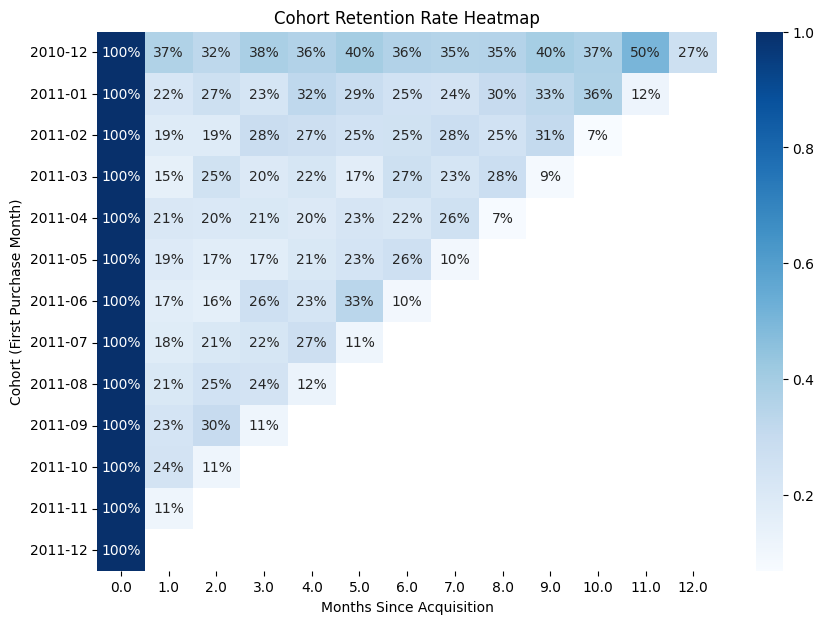

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    normalized_cohort_df,
    annot=True, #puts percent in each cell
    fmt='.0%', # turns 0.18 to 18%
    cmap='Blues',
)

plt.title('Cohort Retention Rate Heatmap')
plt.xlabel('Months Since Acquisition')
plt.ylabel('Cohort (First Purchase Month)')
plt.show()

# Average Revenue by Cohort
Revenue per line item instead of a headcount.

Using **median**, not mean: a single ~£168k outlier order (one row, cohort 2011-05) skewed data

or we could've just dropped that one outlier

In [9]:
average_sales = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].pivot_table(
    index='FirstPurchaseMonth', columns='PeriodSinceAcquisition', values='total_payment', aggfunc='median'
)
average_sales.round(2)

PeriodSinceAcquisition,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
FirstPurchaseMonth,,,,,,,,,,,,,
2010-12,11.25,13.52,12.60,11.90,11.70,13.20,11.70,10.50,12.45,12.75,13.2,10.08,11.7
2011-01,11.70,11.25,10.20,9.96,12.75,14.75,14.22,12.48,10.50,10.50,8.8,8.85,NaN
2011-02,14.85,12.60,12.50,15.00,15.00,13.20,15.00,16.50,13.20,15.00,16.5,NaN,NaN
2011-03,14.85,15.00,15.00,14.85,15.00,15.00,15.90,14.94,10.20,5.95,NaN,NaN,NaN
2011-04,14.85,15.00,13.65,15.00,15.00,11.80,12.48,12.48,9.90,NaN,NaN,NaN,NaN
2011-05,15.00,10.20,15.80,16.50,15.60,10.20,14.85,9.69,NaN,NaN,NaN,NaN,NaN
2011-06,11.90,8.50,15.00,15.00,10.20,9.90,6.60,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,10.50,15.90,8.50,9.90,5.04,5.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,13.20,6.64,7.50,8.30,10.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Median Revenue Heatmap

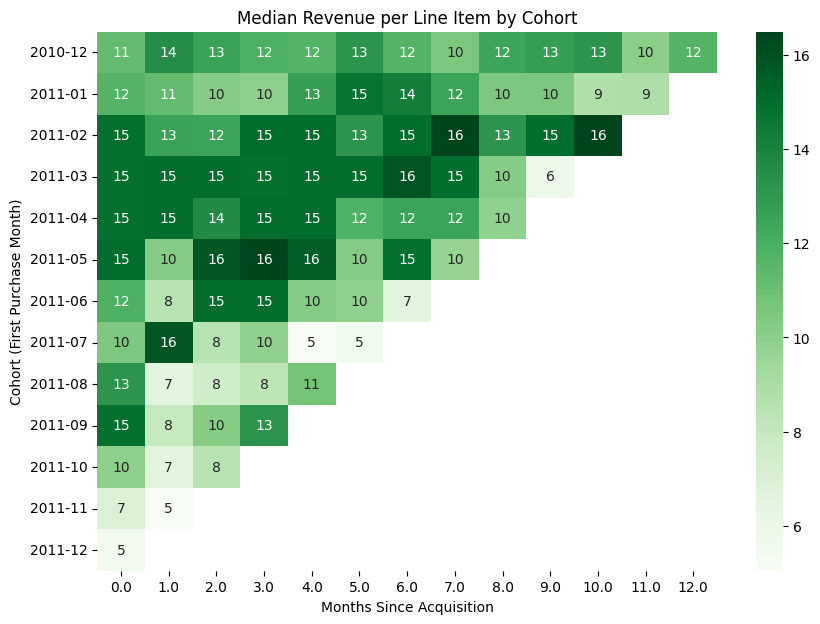

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    average_sales,
    annot=True, fmt='.0f',
    cmap='Greens',
)

plt.title('Median Revenue per Line Item by Cohort')
plt.xlabel('Months Since Acquisition')
plt.ylabel('Cohort (First Purchase Month)')
plt.show()

# Retention Trends Summary

Retention drops off fast after the first month — most one-time buyers don't come back the next month. But after that initial drop, it levels out: customers who return once tend to keep returning at a steady rate rather than fading away gradually.\
\
The December 2010 cohort — the largest, and the only one we can track for a full year — shows the strongest, most stable long-term retention, including a late-year spike. That's probably because it's the earliest cohort (so it's had the most time to show a repeat pattern) and possibly a holiday-season effect (customers acquired in December coming back the following December).\
\
Later cohorts have fewer months of data to observe, and the most recent cohort has almost none beyond month zero — not because those customers stopped buying, but because the dataset simply ends before we could see more. So the sparse later cohorts shouldn't be compared head-to-head with fully-tracked ones like December 2010.\
\
Spending per item, though, doesn't follow the same pattern. While retention swings a lot across cohorts and time, how much customers typically spend per item when they do return stays remarkably flat. So whether someone comes back varies a lot — but how much they spend per item when they do barely changes at all.